In [1]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import datetime
import pandas as pd
import random
import pandas_ta as ta
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('input2lstm.csv', index_col=0, low_memory=False)

In [3]:
df.head(2)

,Close,High,Low,Open,Volume,date,weekday,month,oc,hl,...,GK_Vol_10,GK_Vol_20,OBV,MFM,MFV,AD,CMF_20,FI_13,VROC_10,PVT
0,5993.25,6006.049805,5982.000000,5982.600098,0,02-01-2013,2,1,0.178015,0.402036,...,NaN,NaN,0,-0.064441,0.0,0.0,NaN,NaN,NaN,NaN
1,6009.50,6017.000000,5986.549805,6015.799805,0,03-01-2013,3,1,-0.104721,0.508643,...,NaN,NaN,0,0.507392,0.0,0.0,NaN,0.0,NaN,0.0


In [4]:
df.tail(2)

,Close,High,Low,Open,Volume,date,weekday,month,oc,hl,...,GK_Vol_10,GK_Vol_20,OBV,MFM,MFV,AD,CMF_20,FI_13,VROC_10,PVT
2943,23813.40039,23938.84961,23800.59961,23801.40039,176800,27-12-2024,4,12,0.050417,0.580868,...,0.129435,0.119717,72722400,-0.814817,-144059.6325,39740968.86,-0.030988,11173966.86,-33.558812,333137.2665
2944,23644.90039,23915.34961,23599.30078,23796.90039,364900,30-12-2024,0,12,-0.638739,1.339230,...,0.109060,0.121880,72357500,-0.711439,-259604.2602,39481364.60,-0.109986,-61485650.00,17.671719,330555.2896


In [5]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'date', 'weekday', 'month',
       'oc', 'hl', 'oh', 'ol', 'co', 'SMA_10', 'SMA_50', 'SMA_100', 'EMA_5',
       'EMA_10', 'EMA_20', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
       'KAMA', 'TMA_20', 'RSI_7', 'RSI_14', '%D', 'ROC_5', 'ROC_10', 'ROC_20',
       'CCI_14', 'CCI_50', 'MOM_10', 'UO', 'KST', 'KST_Signal', 'BB_Upper',
       'BB_Middle', 'BB_Lower', 'BB_PercentB', 'HL_Range', 'HL_EMA', 'CVI',
       'STDDEV_10', 'STDDEV_20', 'Log_Returns', 'HV_10', 'HV_20', 'GK_Vol_10',
       'GK_Vol_20', 'OBV', 'MFM', 'MFV', 'AD', 'CMF_20', 'FI_13', 'VROC_10',
       'PVT'],
      dtype='object')

In [6]:
df['Target']=np.where(df['oc'].values<-0.15,0,np.where(df['oc'].values<0.15,1,2))
df['Target']=df['Target'].shift(-1)

In [7]:
 df["lstmstate"] = None

In [8]:
 df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'date', 'weekday', 'month',
       'oc', 'hl', 'oh', 'ol', 'co', 'SMA_10', 'SMA_50', 'SMA_100', 'EMA_5',
       'EMA_10', 'EMA_20', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
       'KAMA', 'TMA_20', 'RSI_7', 'RSI_14', '%D', 'ROC_5', 'ROC_10', 'ROC_20',
       'CCI_14', 'CCI_50', 'MOM_10', 'UO', 'KST', 'KST_Signal', 'BB_Upper',
       'BB_Middle', 'BB_Lower', 'BB_PercentB', 'HL_Range', 'HL_EMA', 'CVI',
       'STDDEV_10', 'STDDEV_20', 'Log_Returns', 'HV_10', 'HV_20', 'GK_Vol_10',
       'GK_Vol_20', 'OBV', 'MFM', 'MFV', 'AD', 'CMF_20', 'FI_13', 'VROC_10',
       'PVT', 'Target', 'lstmstate'],
      dtype='object')

In [9]:
df.tail()

,Close,High,Low,Open,Volume,date,weekday,month,oc,hl,...,OBV,MFM,MFV,AD,CMF_20,FI_13,VROC_10,PVT,Target,lstmstate
2940,23753.44922,23869.55078,23647.19922,23738.19922,189800,23-12-2024,0,12,0.064242,0.940287,...,72545600,-0.044306,-8409.323002,39986775.93,-0.041960,3.149716e+07,-23.498589,332690.9176,0.0,None
2941,23727.65039,23867.65039,23685.15039,23769.09961,177700,24-12-2024,1,12,-0.174383,0.770525,...,72367900,-0.534247,-94935.616440,39891840.31,-0.044291,-4.584452e+06,-31.915709,332497.9160,1.0,None
2942,23750.19922,23854.50000,23653.59961,23775.80078,177700,26-12-2024,3,12,-0.107679,0.849344,...,72545600,-0.038333,-6811.823058,39885028.49,-0.059586,4.006927e+06,-5.125467,332666.7877,1.0,None
2943,23813.40039,23938.84961,23800.59961,23801.40039,176800,27-12-2024,4,12,0.050417,0.580868,...,72722400,-0.814817,-144059.632500,39740968.86,-0.030988,1.117397e+07,-33.558812,333137.2665,0.0,None
2944,23644.90039,23915.34961,23599.30078,23796.90039,364900,30-12-2024,0,12,-0.638739,1.339230,...,72357500,-0.711439,-259604.260200,39481364.60,-0.109986,-6.148565e+07,17.671719,330555.2896,NaN,None


In [10]:
# Drop the last row (as it has no next-day price)
df = df[:-1]

In [11]:
df = df[100:].reset_index(drop=False)  # Drop first 55 rows and reset index

In [12]:
df.head(2)

,index,Close,High,Low,Open,Volume,date,weekday,month,oc,...,OBV,MFM,MFV,AD,CMF_20,FI_13,VROC_10,PVT,Target,lstmstate
0,100,6104.299805,6125.049805,6069.799805,6120.450195,120200,29-05-2013,2,5,-0.263876,...,-94800,0.248869,29914.02715,-330473.0473,0.097321,-835413.439,-21.897336,-3061.705179,2.0,None
1,101,6124.049805,6133.750000,6072.149902,6072.149902,194100,30-05-2013,3,5,0.854720,...,99300,0.685059,132969.97230,-197503.0750,0.107417,3833475.000,22.383354,-2433.709319,0.0,None


In [13]:
df.columns

Index(['index', 'Close', 'High', 'Low', 'Open', 'Volume', 'date', 'weekday',
       'month', 'oc', 'hl', 'oh', 'ol', 'co', 'SMA_10', 'SMA_50', 'SMA_100',
       'EMA_5', 'EMA_10', 'EMA_20', 'MACD_12_26_9', 'MACDh_12_26_9',
       'MACDs_12_26_9', 'KAMA', 'TMA_20', 'RSI_7', 'RSI_14', '%D', 'ROC_5',
       'ROC_10', 'ROC_20', 'CCI_14', 'CCI_50', 'MOM_10', 'UO', 'KST',
       'KST_Signal', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_PercentB',
       'HL_Range', 'HL_EMA', 'CVI', 'STDDEV_10', 'STDDEV_20', 'Log_Returns',
       'HV_10', 'HV_20', 'GK_Vol_10', 'GK_Vol_20', 'OBV', 'MFM', 'MFV', 'AD',
       'CMF_20', 'FI_13', 'VROC_10', 'PVT', 'Target', 'lstmstate'],
      dtype='object')

In [14]:
# Select features (5 indicators)
features = ['weekday',
       'month', 'oc', 'hl', 'oh', 'ol', 'co', 'SMA_10', 'SMA_50', 'SMA_100',
       'EMA_5', 'EMA_10', 'EMA_20', 'MACD_12_26_9', 'MACDh_12_26_9',
       'MACDs_12_26_9', 'KAMA', 'TMA_20', 'RSI_7', 'RSI_14', '%D', 'ROC_5',
       'ROC_10', 'ROC_20', 'CCI_14', 'CCI_50', 'MOM_10', 'UO', 'KST',
       'KST_Signal', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_PercentB',
       'HL_Range', 'HL_EMA', 'CVI', 'STDDEV_10', 'STDDEV_20', 'Log_Returns',
       'HV_10', 'HV_20', 'GK_Vol_10', 'GK_Vol_20', 'OBV', 'MFM', 'MFV', 'AD',
       'CMF_20', 'FI_13', 'VROC_10', 'PVT']
target = 'Target'

In [15]:
# Normalize data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

In [16]:
# Convert data into sequences for LSTM
sequence_length = 60  # Use past 60 days to predict next day

def create_sequences(data, features, target, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[features].iloc[i:i+seq_length].values)
        y.append(data[target].iloc[i+seq_length])
    return np.array(X), np.array(y)

#X, y = create_sequences(df.iloc[55:], features, target, sequence_length)
X, y = create_sequences(df, features, target, sequence_length)

In [17]:
len(X)

2784

In [18]:
X.shape

(2784, 60, 52)

In [19]:
X[0].shape

(60, 52)

In [20]:
len(y)

2784

In [21]:
df.shape

(2844, 61)

In [22]:
print(df.iloc[2152])

index               2252
Close        16345.34961
High         16418.05078
Low              15990.0
Open             16078.0
                ...     
FI_13           0.713403
VROC_10         0.000332
PVT             0.819998
Target               0.0
lstmstate           None
Name: 2152, Length: 61, dtype: object


In [23]:
# Define train-test split index
#split_idx = int(len(X) * 0.8)  # 80% training, 20% testing
split_idx = 2153 
# Split without shuffling
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 2153, Test size: 631


In [24]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer,Input, LSTM, Dense, RepeatVector, TimeDistributed, Attention, Multiply
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers import SGD

# Define Attention Layer
class AttentionLayer(Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()
        self.dense = tf.keras.layers.Dense(1, activation="tanh")  # Moved here
        self.softmax = tf.keras.layers.Softmax(axis=1)

    def call(self, lstm_output):
        attention = self.dense(lstm_output)  # Uses pre-defined layer
        attention = self.softmax(attention)
        context_vector = Multiply()([lstm_output, attention])
        return tf.reduce_sum(context_vector, axis=1)  # Context vector output

# Build Attention LSTM Model
def build_model(input_shape, lstm_units=[256, 128], dense_units=[64]):
    inputs = Input(shape=input_shape)
    
    # LSTM layers
    lstm_out = LSTM(lstm_units[0], return_sequences=True)(inputs)  # First LSTM layer
    lstm_out = Dropout(0.2)(lstm_out)
    lstm_out = BatchNormalization()(lstm_out)
    lstm_out = LSTM(lstm_units[1], return_sequences=True)(lstm_out)  # Second LSTM layer
    lstm_out = Dropout(0.2)(lstm_out)
    lstm_out = BatchNormalization()(lstm_out)

    # Attention layer
    attention_out = AttentionLayer()(lstm_out)

    # Dense layers
    dense_out = attention_out
    for units in dense_units:
        dense_out = Dense(units)(dense_out)  # Add hidden dense layers
        dense_out = BatchNormalization()(dense_out) 
        dense_out = LeakyReLU(alpha=0.01)(dense_out)

    output = Dense(3, activation='softmax')(dense_out)  # Output layer
    
    model = Model(inputs, output)
    #model.compile(optimizer=AdamW(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [25]:
# Example: Using 2 LSTM layers (64 and 32 neurons), 2 Dense layers (16 and 8 neurons)
input_shape = (sequence_length, len(features))  # 60 time steps, 52 indicators
model = build_model(input_shape, lstm_units=[256, 128], dense_units=[64, 64])
model.summary()

C:\Users\IIITNAGPUR\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 60, 52)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 60, 256)             │         316,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 60, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 128)             │         197,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 60, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer (AttentionLayer)     │ (None, 128)                 │             129 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 528,324 (2.02 MB)

 Trainable params: 527,300 (2.01 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [26]:
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step - accuracy: 0.3861 - loss: 1.1514 - val_accuracy: 0.3930 - val_loss: 1.0777
Epoch 2/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.4446 - loss: 1.0503 - val_accuracy: 0.3930 - val_loss: 1.1074
Epoch 3/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.4487 - loss: 1.0480 - val_accuracy: 0.3788 - val_loss: 1.0865
Epoch 4/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.4465 - loss: 1.0505 - val_accuracy: 0.3899 - val_loss: 1.0853
Epoch 5/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.4443 - loss: 1.0377 - val_accuracy: 0.3930 - val_loss: 1.1684
Epoch 6/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - accuracy: 0.4261 - loss: 1.0444 - val_accuracy: 0.3930 - val_loss: 1.1050
Epoch 7/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.4419 - loss: 1.0283 - val_accuracy: 0.3962 - val_loss: 1.0950
Epoch 8/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.4343 - loss: 1.0286 - val_

In [27]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4264 - loss: 1.0667
Test Accuracy: 0.40


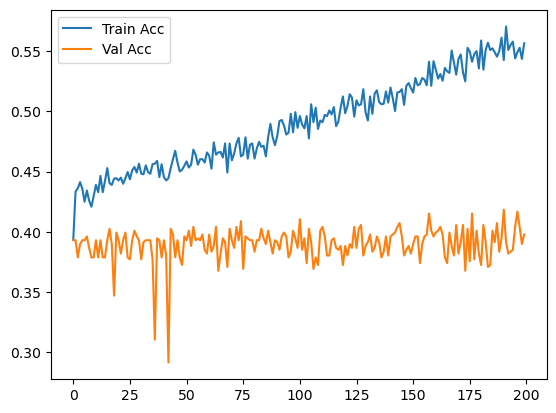

In [28]:

# Plot Training History
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

In [29]:
# Make a prediction
predicted = model.predict(X)
print(predicted)
#print("Predicted Trend:", "UP" if predicted[0] > 0.5 else "DOWN")

87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step
[[0.69673675 0.08283196 0.22043124]
 [0.60483515 0.03673133 0.3584335 ]
 [0.11485818 0.00090132 0.88424045]
 ...
 [0.3520323  0.15280864 0.49515903]
 [0.43585134 0.11173435 0.4524143 ]
 [0.5229627  0.09130158 0.3857357 ]]


In [30]:
# Convert probabilities to class labels
predicted_classes = np.argmax(predicted, axis=1)  # Get the index of the max value per row

In [31]:
predicted_classes.shape

(2784,)

In [32]:
# Get unique elements and their frequencies
unique_elements, counts = np.unique(predicted_classes, return_counts=True)

# Display results
for element, count in zip(unique_elements, counts):
    print(f"Element: {element}, Frequency: {count}")

Element: 0, Frequency: 1222
Element: 1, Frequency: 300
Element: 2, Frequency: 1262


In [33]:
df.shape

(2844, 61)

In [34]:
df.iloc[60:, df.columns.get_loc("lstmstate")] = predicted_classes

In [35]:
# Compute percentage change in tomorrow's Open price relative to today's Close
df["p_co"] = ((df["Open"].shift(-1)-df["Close"]) / df["Close"]) * 100

In [36]:
# Apply condition, keeping NaNs unchanged
df['state'] = np.where(df['p_co'] > 0, df['lstmstate'] + 3, df['lstmstate'])

In [37]:
df['state'].describe()

count     2784
unique       6
top          5
freq       881
Name: state, dtype: int64

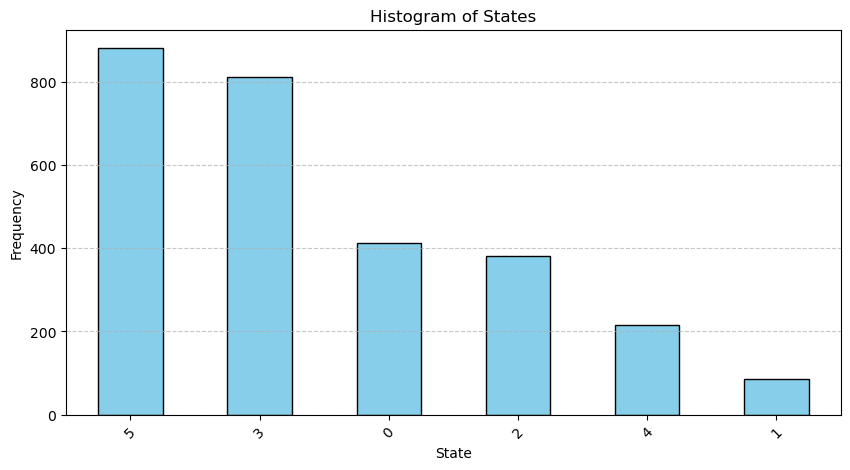

In [38]:
# Plot histogram for categorical data
df['state'].value_counts().plot(kind='bar', figsize=(10, 5), color='skyblue', edgecolor='black')

plt.xlabel('State')
plt.ylabel('Frequency')
plt.title('Histogram of States')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [39]:
#df.index = pd.to_datetime(df.index)
df = df.reset_index(drop=True)
df.to_csv('temp.csv', index=True) 

In [40]:
len(df)

2844